In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/raw/insurance_100k_clean.csv')

print("Shape:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)
print("\nEstatísticas descritivas:")
df.describe()

Shape: (99989, 7)

Tipos de dados:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Estatísticas descritivas:


,age,bmi,children,charges
count,99989.000000,99989.000000,99989.000000,99989.000000
mean,40.189891,30.700918,1.118603,18944.439172
std,9.393535,6.060493,1.257320,15331.995101
min,18.000000,15.000000,0.000000,2024.140000
25%,33.000000,26.570000,0.000000,9438.260000
50%,40.000000,30.680000,1.000000,13461.100000
75%,47.000000,34.800000,2.000000,20619.750000
max,63.000000,53.000000,5.000000,65000.000000


In [2]:
# Verificar valores vazios opu nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())

print("\nValores duplicados:", df.duplicated().sum())

print("\nDistribuição das variáveis:")
print("\nSexo:\n", df['sex'].value_counts())
print("\nFumante:\n", df['smoker'].value_counts())
print("\nRegião:\n", df['region'].value_counts())

Valores nulos por coluna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Valores duplicados: 0

Distribuição das variáveis:

Sexo:
 sex
male      50601
female    49388
Name: count, dtype: int64

Fumante:
 smoker
no     79926
yes    20063
Name: count, dtype: int64

Região:
 region
southeast    27006
northeast    24934
northwest    24180
southwest    23869
Name: count, dtype: int64


In [7]:
# Dataset já está limpo — entao vou apenas salvar como processed
df.to_csv('../data/processed/insurance_clean.csv', index=False)
print("Shape:", df.shape)
print("Arquivo salvo em data/processed/insurance_clean.csv")

Shape: (99989, 7)
Arquivo salvo em data/processed/insurance_clean.csv


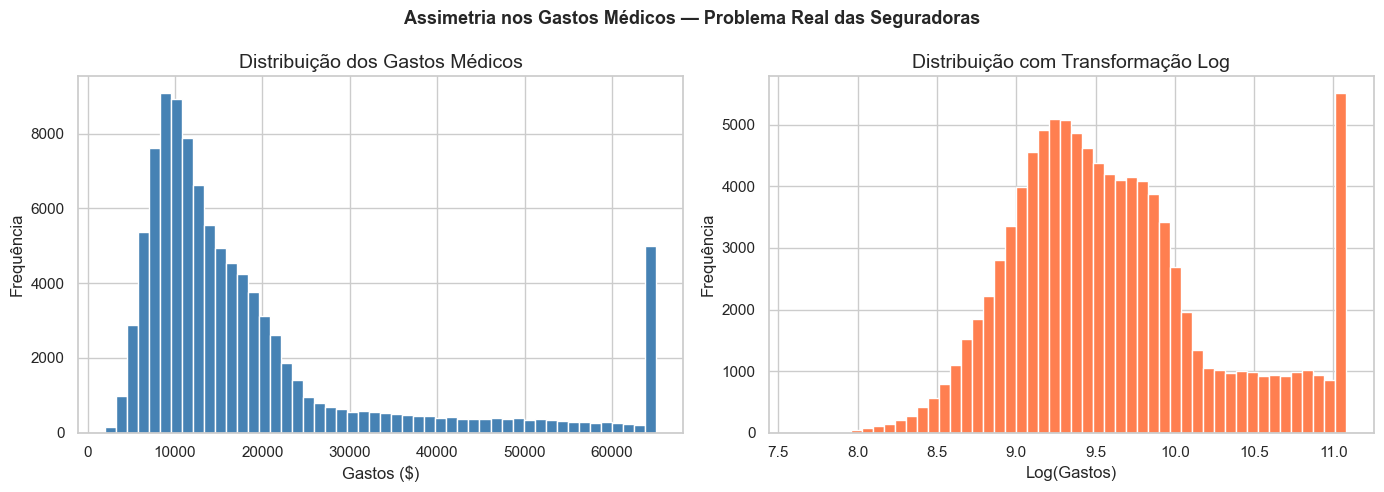


Assimetria (skewness) original: 1.87
Assimetria após log: 0.63


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição original
axes[0].hist(df['charges'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição dos Gastos Médicos', fontsize=14)
axes[0].set_xlabel('Gastos ($)')
axes[0].set_ylabel('Frequência')

# Distribuição com log
axes[1].hist(np.log(df['charges']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribuição com Transformação Log', fontsize=14)
axes[1].set_xlabel('Log(Gastos)')
axes[1].set_ylabel('Frequência')

plt.suptitle('Assimetria nos Gastos Médicos — Problema Real das Seguradoras',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nAssimetria (skewness) original: {df['charges'].skew():.2f}")
print(f"Assimetria após log: {np.log(df['charges']).skew():.2f}")

C:\Users\gusta\AppData\Local\Temp\ipykernel_17700\516400334.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette={'yes':'tomato','no':'steelblue'}, ax=axes[0])


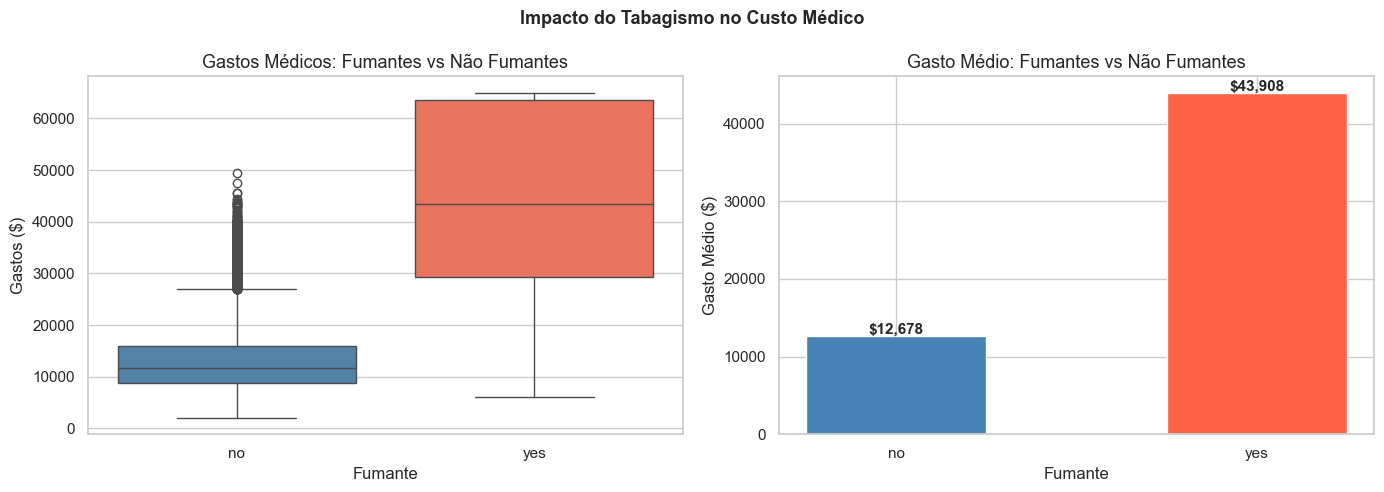

Gasto médio não fumante: $12,678.06
Gasto médio fumante:     $43,908.12
Fumantes custam 3.5x mais para a seguradora


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=df, x='smoker', y='charges', palette={'yes':'tomato','no':'steelblue'}, ax=axes[0])
axes[0].set_title('Gastos Médicos: Fumantes vs Não Fumantes', fontsize=13)
axes[0].set_xlabel('Fumante')
axes[0].set_ylabel('Gastos ($)')

# Médias
medias = df.groupby('smoker')['charges'].mean().reset_index()
bars = axes[1].bar(medias['smoker'], medias['charges'],
                   color=['steelblue','tomato'], edgecolor='white', width=0.5)
axes[1].set_title('Gasto Médio: Fumantes vs Não Fumantes', fontsize=13)
axes[1].set_xlabel('Fumante')
axes[1].set_ylabel('Gasto Médio ($)')
for bar, val in zip(bars, medias['charges']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 300,
                 f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Impacto do Tabagismo no Custo Médico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Números
nao_fumante = df[df['smoker']=='no']['charges'].mean()
fumante = df[df['smoker']=='yes']['charges'].mean()
print(f"Gasto médio não fumante: ${nao_fumante:,.2f}")
print(f"Gasto médio fumante:     ${fumante:,.2f}")
print(f"Fumantes custam {fumante/nao_fumante:.1f}x mais para a seguradora")

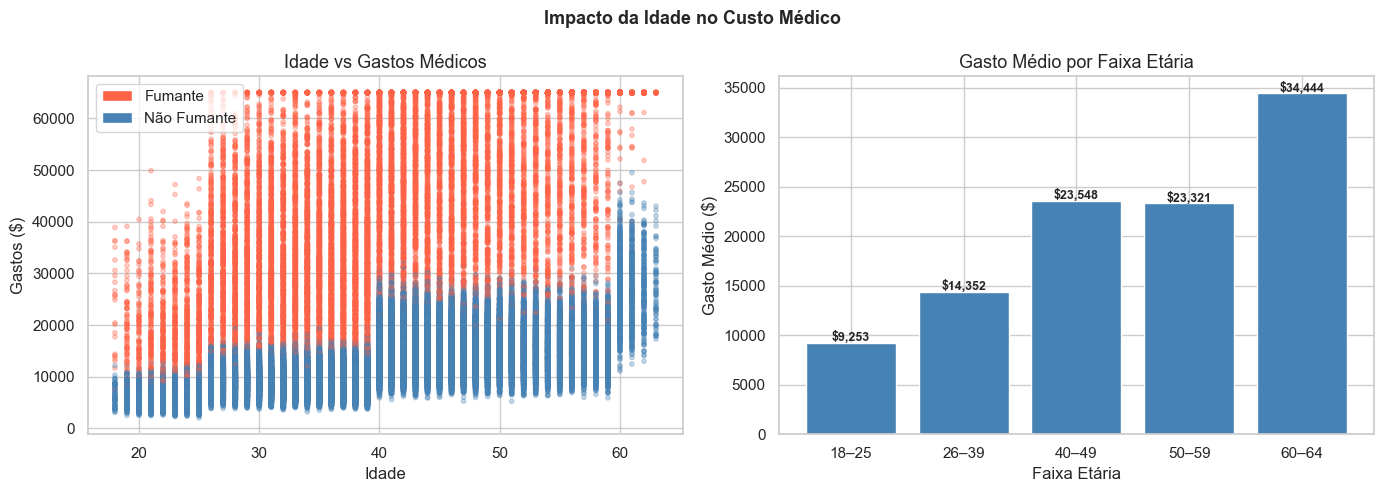

Correlação idade-charges: 0.301


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter idade vs charges
colors = df['smoker'].map({'yes': 'tomato', 'no': 'steelblue'})
axes[0].scatter(df['age'], df['charges'], c=colors, alpha=0.3, s=10)
axes[0].set_title('Idade vs Gastos Médicos', fontsize=13)
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Gastos ($)')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tomato', label='Fumante'),
                   Patch(facecolor='steelblue', label='Não Fumante')]
axes[0].legend(handles=legend_elements)

# Gasto médio por faixa etária
bins = [18, 25, 39, 49, 59, 64]
labels = ['18–25', '26–39', '40–49', '50–59', '60–64']
df['faixa_etaria'] = pd.cut(df['age'], bins=bins, labels=labels, include_lowest=True)
media_faixa = df.groupby('faixa_etaria', observed=True)['charges'].mean()
axes[1].bar(media_faixa.index, media_faixa.values, color='steelblue', edgecolor='white')
axes[1].set_title('Gasto Médio por Faixa Etária', fontsize=13)
axes[1].set_xlabel('Faixa Etária')
axes[1].set_ylabel('Gasto Médio ($)')
for i, (idx, val) in enumerate(media_faixa.items()):
    axes[1].text(i, val + 200, f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Impacto da Idade no Custo Médico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Remover coluna temporária
df = df.drop(columns=['faixa_etaria'])

print("Correlação idade-charges:", df['age'].corr(df['charges']).round(3))

C:\Users\gusta\AppData\Local\Temp\ipykernel_17700\3041708775.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='obeso', y='charges',


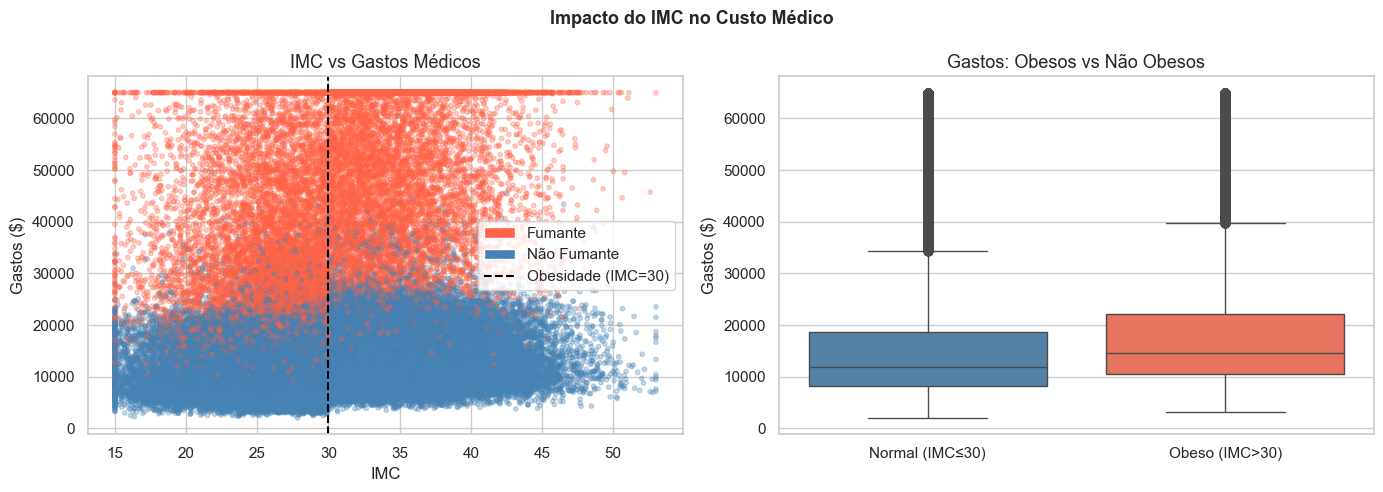

Gasto médio obesos:     $21,324.17
Gasto médio não obesos: $16,107.52
Correlação IMC-charges: 0.136


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter IMC vs charges colorido por fumante
colors = df['smoker'].map({'yes': 'tomato', 'no': 'steelblue'})
axes[0].scatter(df['bmi'], df['charges'], c=colors, alpha=0.3, s=10)
axes[0].axvline(x=30, color='black', linestyle='--', linewidth=1.5, label='Obesidade (IMC=30)')
axes[0].set_title('IMC vs Gastos Médicos', fontsize=13)
axes[0].set_xlabel('IMC')
axes[0].set_ylabel('Gastos ($)')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tomato', label='Fumante'),
                   Patch(facecolor='steelblue', label='Não Fumante'),
                   plt.Line2D([0],[0], color='black', linestyle='--', label='Obesidade (IMC=30)')]
axes[0].legend(handles=legend_elements)

# Boxplot obeso vs não obeso
df['obeso'] = df['bmi'].apply(lambda x: 'Obeso (IMC>30)' if x > 30 else 'Normal (IMC≤30)')
sns.boxplot(data=df, x='obeso', y='charges',
            palette={'Obeso (IMC>30)':'tomato', 'Normal (IMC≤30)':'steelblue'},
            ax=axes[1])
axes[1].set_title('Gastos: Obesos vs Não Obesos', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Gastos ($)')

plt.suptitle('Impacto do IMC no Custo Médico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

df = df.drop(columns=['obeso'])

media_obeso = df[df['bmi'] > 30]['charges'].mean()
media_normal = df[df['bmi'] <= 30]['charges'].mean()
print(f"Gasto médio obesos:     ${media_obeso:,.2f}")
print(f"Gasto médio não obesos: ${media_normal:,.2f}")
print(f"Correlação IMC-charges: {df['bmi'].corr(df['charges']):.3f}")

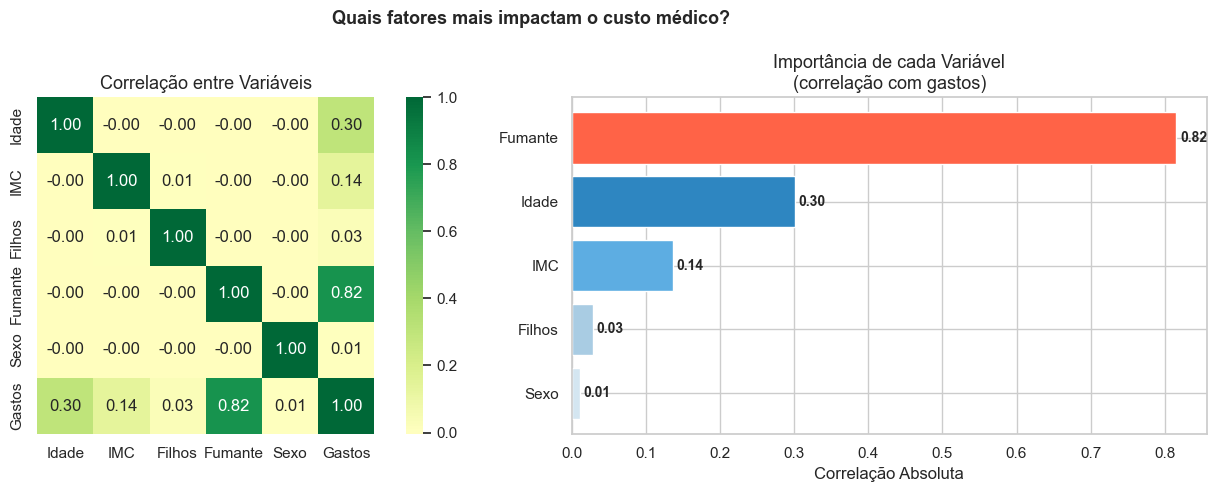

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# variáveis categóricas para correlação
df_enc = df.copy()
df_enc['smoker_num'] = (df_enc['smoker'] == 'yes').astype(int)
df_enc['sex_num'] = (df_enc['sex'] == 'male').astype(int)

# Heatmap
cols = ['age', 'bmi', 'children', 'smoker_num', 'sex_num', 'charges']
corr = df_enc[cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], square=True,
            xticklabels=['Idade','IMC','Filhos','Fumante','Sexo','Gastos'],
            yticklabels=['Idade','IMC','Filhos','Fumante','Sexo','Gastos'])
axes[0].set_title('Correlação entre Variáveis', fontsize=13)

# Barras de correlação com charges
corr_charges = corr['charges'].drop('charges').abs().sort_values(ascending=True)
labels = ['Sexo', 'Filhos', 'IMC', 'Idade', 'Fumante']
bars = axes[1].barh(labels, corr_charges.values,
                    color=['#d4e6f1','#a9cce3','#5dade2','#2e86c1','tomato'],
                    edgecolor='white')
axes[1].set_title('Importância de cada Variável\n(correlação com gastos)', fontsize=13)
axes[1].set_xlabel('Correlação Absoluta')
for bar, val in zip(bars, corr_charges.values):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Quais fatores mais impactam o custo médico?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
print("=" * 55)
print("   RESUMO EDA — INSIGHTS DE NEGÓCIO")
print("=" * 55)

total = len(df)
fumantes = (df['smoker'] == 'yes').sum()
obesos = (df['bmi'] > 30).sum()
fumantes_obesos = ((df['smoker'] == 'yes') & (df['bmi'] > 30)).sum()
alto_custo = (df['charges'] > 40000).sum()

print(f"\n Base: {total:,} beneficiários")
print(f"\n Fumantes: {fumantes:,} ({fumantes/total*100:.1f}%)")
print(f"   → Custam ${df[df['smoker']=='yes']['charges'].mean():,.0f}/ano em média")
print(f"   → 3.5x mais caro que não fumantes")

print(f"\n  Obesos (IMC>30): {obesos:,} ({obesos/total*100:.1f}%)")
print(f"   → Custam ${df[df['bmi']>30]['charges'].mean():,.0f}/ano em média")

print(f"\n Fumantes obesos: {fumantes_obesos:,} ({fumantes_obesos/total*100:.1f}%)")
print(f"   → Custo médio: ${df[(df['smoker']=='yes') & (df['bmi']>30)]['charges'].mean():,.0f}/ano")

print(f"\n Alto custo (>$40k): {alto_custo:,} ({alto_custo/total*100:.1f}%)")
print(f"   → Gasto total desse grupo: ${df[df['charges']>40000]['charges'].sum():,.0f}")

print(f"\n Correlações com charges:")
print(f"   Fumante: 0.82 | Idade: 0.30 | IMC: 0.14")

print("\n" + "=" * 55)
print(" EDA concluído — pronto para Feature Engineering")
print("=" * 55)

   RESUMO EDA — INSIGHTS DE NEGÓCIO

 Base: 99,989 beneficiários

 Fumantes: 20,063 (20.1%)
   → Custam $43,908/ano em média
   → 3.5x mais caro que não fumantes

  Obesos (IMC>30): 54,376 (54.4%)
   → Custam $21,324/ano em média

 Fumantes obesos: 10,849 (10.9%)
   → Custo médio: $51,462/ano

 Alto custo (>$40k): 11,179 (11.2%)
   → Gasto total desse grupo: $637,227,580

 Correlações com charges:
   Fumante: 0.82 | Idade: 0.30 | IMC: 0.14

 EDA concluído — pronto para Feature Engineering
